In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
warnings.filterwarnings("ignore")

# Настройка отображения графиков
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 1.19.5
Pandas: 1.1.5
TensorFlow: 2.6.2


In [2]:
# ============================================================
# 2. Фиксация случайности
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Набор seed для проверки устойчивости результатов
SEEDS_FOR_EXPERIMENT = [1, 2, 3, 4, 5]

print(f"\nОсновной random seed: {SEED}")


Основной random seed: 42


In [3]:
# ============================================================
# 3. Формулировка исследования
# ============================================================

research_question = (
    "Как выбор оптимизатора влияет на качество и скорость обучения "
    "нейронной сети при прогнозировании стоимости жилья?"
)

hypothesis = (
    "SGD с momentum и Adam будут сходиться быстрее обычного SGD "
    "и дадут меньшую ошибку на тестовой выборке."
)

print("\nИсследовательский вопрос:")
print(research_question)

print("\nГипотеза:")
print(hypothesis)



Исследовательский вопрос:
Как выбор оптимизатора влияет на качество и скорость обучения нейронной сети при прогнозировании стоимости жилья?

Гипотеза:
SGD с momentum и Adam будут сходиться быстрее обычного SGD и дадут меньшую ошибку на тестовой выборке.


In [4]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)    # если scikit-learn версия > 0.23

X = data.data
y = data.target

print(X.shape)
print(X.head())
print(y.head())

TypeError: fetch_california_housing() got an unexpected keyword argument 'as_frame'

In [6]:
 # если scikit-learn версия < 0.23
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="MedHouseVal"
)

print(X.shape)
print(X.head())
print(y.head())

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [8]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["MedHouseVal"] = housing.target

df = df.rename(
    columns={
        "MedHouseVal": "target"
    }
)

In [9]:

display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
# ============================================================
# 5. Общая информация о данных
# ============================================================

print("\nНазвания столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
display(df.dtypes.to_frame("dtype"))

print("\nРазмер таблицы:")
print(df.shape)

print("\nСлучайные строки:")
display(
    df.sample(
        n=5,
        random_state=SEED
    )
)




Названия столбцов:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'target']

Типы данных:


,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
target,float64



Размер таблицы:
(20640, 9)

Случайные строки:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


In [11]:
# ============================================================
# 6. Проверка пропусков
# ============================================================

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_table = missing_table.sort_values(
    by="missing_count",
    ascending=False
)

print("\nПропуски:")
display(missing_table)

if df.isna().sum().sum() == 0:
    print("Пропуски не обнаружены.")
else:
    print("В данных есть пропуски.")


Пропуски:


,missing_count,missing_percent
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
target,0,0.0


Пропуски не обнаружены.


In [12]:
# ============================================================
# 7. Проверка дубликатов
# ============================================================

duplicate_count = df.duplicated().sum()

print("\nКоличество полных дубликатов:", duplicate_count)

if duplicate_count > 0:
    display(
        df[
            df.duplicated(keep=False)
        ].head()
    )



Количество полных дубликатов: 0


In [13]:
# ============================================================
# 8. Статистическое описание
# ============================================================

print("\nСтатистическое описание:")
display(df.describe().T)

statistics = df.describe().T

statistics["missing"] = df.isna().sum()
statistics["unique"] = df.nunique()

print("\nРасширенная статистика:")
display(statistics)


Статистическое описание:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010



Расширенная статистика:


,count,mean,std,min,25%,50%,75%,max,missing,unique
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100,0,12928
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000,0,52
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091,0,19392
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667,0,14233
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000,0,3888
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333,0,18841
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000,0,862
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000,0,844
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010,0,3842



Анализ целевой переменной:
Минимум: 0.14999
Максимум: 5.00001
Среднее: 2.068558169089147
Медиана: 1.797
Стандартное отклонение: 1.1539561587441387


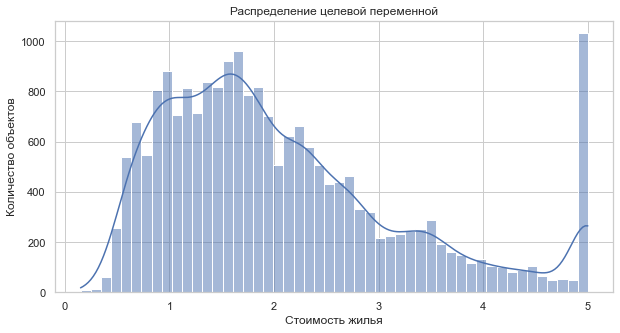

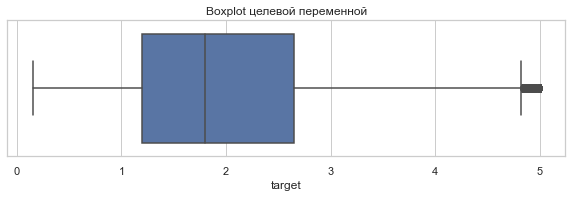

In [14]:
# ============================================================
# 9. Анализ целевой переменной
# ============================================================

print("\nАнализ целевой переменной:")

print("Минимум:", df['target'].min())
print("Максимум:", df['target'].max())
print("Среднее:", df['target'].mean())
print("Медиана:", df['target'].median())
print("Стандартное отклонение:", df['target'].std())

# Гистограмма целевой переменной
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='target',
    bins=50,
    kde=True
)

plt.title("Распределение целевой переменной")
plt.xlabel("Стоимость жилья")
plt.ylabel("Количество объектов")
plt.show()

# Boxplot целевой переменной
plt.figure(figsize=(10, 2.5))

sns.boxplot(
    data=df,
    x='target'
)

plt.title("Boxplot целевой переменной")
plt.show()


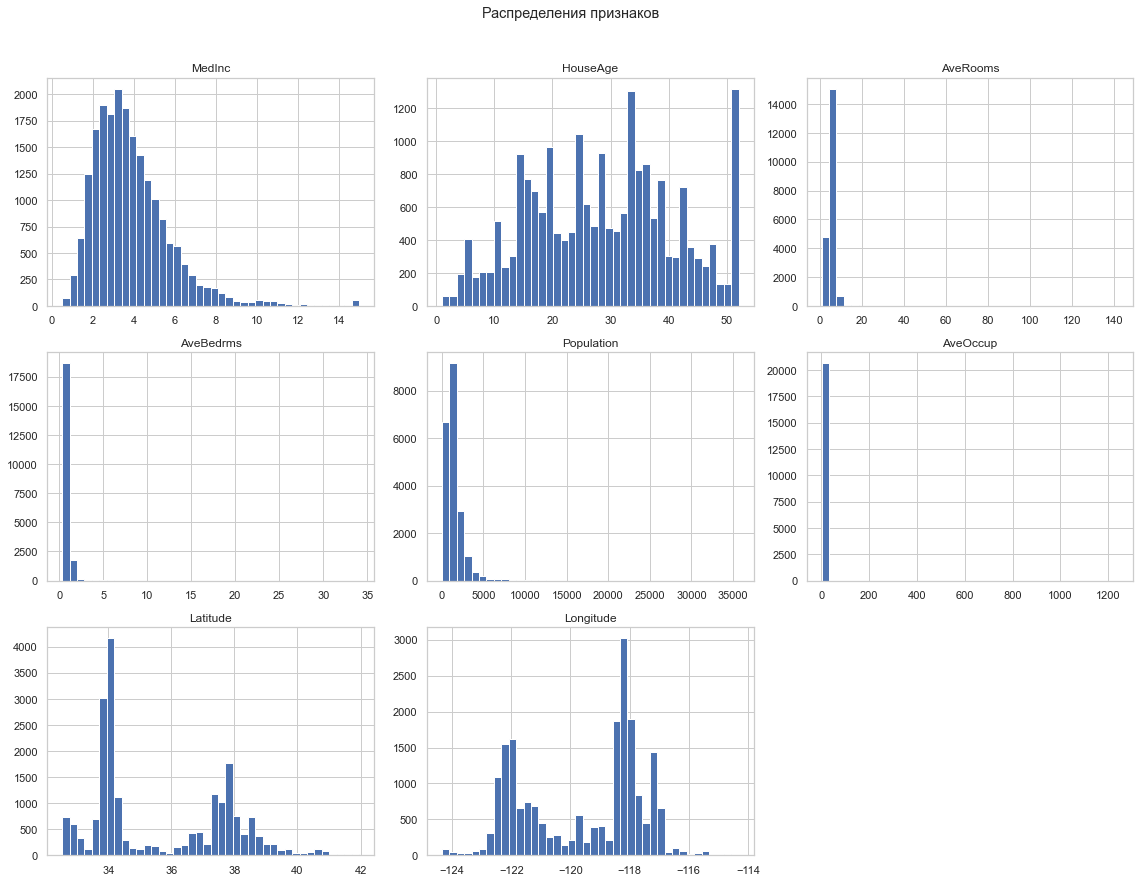

In [15]:
# ============================================================
# 10. Анализ распределений признаков
# ============================================================

feature_columns = [
    column
    for column in df.columns
    if column != 'target'
]

df[feature_columns].hist(
    bins=40,
    figsize=(16, 12),
    layout=(3, 3)
)

plt.suptitle(
    "Распределения признаков",
    y=1.02
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 11. Анализ выбросов по правилу IQR
# ============================================================

def count_iqr_outliers(series):
    """
    Вычисляет границы выбросов по правилу IQR.

    Возвращает:
    - нижнюю границу;
    - верхнюю границу;
    - количество выбросов.
    """

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    return (
        lower_bound,
        upper_bound,
        outlier_mask.sum()
    )


outlier_rows = []

for column in df.select_dtypes(
    include=np.number
).columns:

    lower, upper, count = count_iqr_outliers(
        df[column]
    )

    outlier_rows.append({
        "feature": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percent": count / len(df) * 100
    })

outlier_table = pd.DataFrame(outlier_rows)

print("\nАнализ выбросов:")
display(
    outlier_table.sort_values(
        by="outlier_count",
        ascending=False
    )
)


Анализ выбросов:


,feature,lower_bound,upper_bound,outlier_count,outlier_percent
3,AveBedrms,0.865909,1.239697,1424,6.899225
4,Population,-620.000000,3132.000000,1196,5.794574
8,target,-0.980875,4.824125,1071,5.188953
5,AveOccup,1.150961,4.561041,711,3.444767
0,MedInc,-0.706375,8.013025,681,3.299419
2,AveRooms,2.023219,8.469878,511,2.475775
1,HouseAge,-10.500000,65.500000,0,0.000000
6,Latitude,28.260000,43.380000,0,0.000000
7,Longitude,-127.485000,-112.325000,0,0.000000


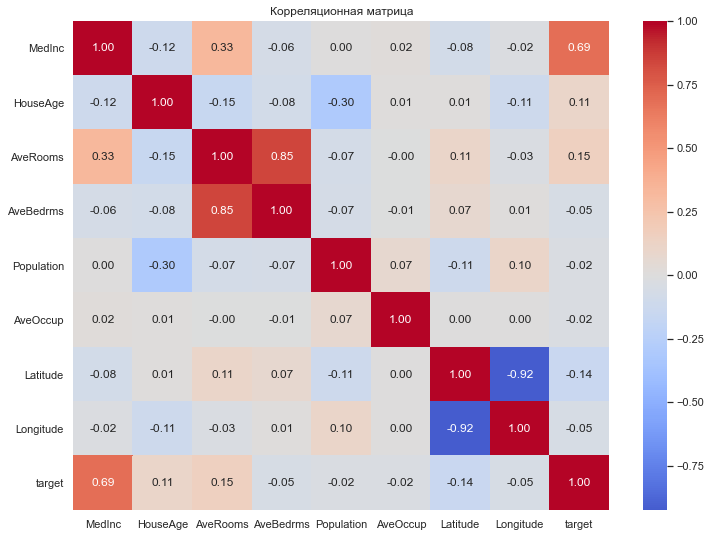


Корреляции признаков с целевой переменной:


,correlation_with_target
MedInc,0.688075
AveRooms,0.151948
Latitude,-0.144160
HouseAge,0.105623
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737


In [17]:
# ============================================================
# 12. Корреляционный анализ
# ============================================================

correlation_matrix = df.corr(
   
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Корреляционная матрица")
plt.show()

target_correlations = (
    correlation_matrix['target']
    .drop('target')
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

print("\nКорреляции признаков с целевой переменной:")
display(
    target_correlations.to_frame(
        "correlation_with_target"
    )
)

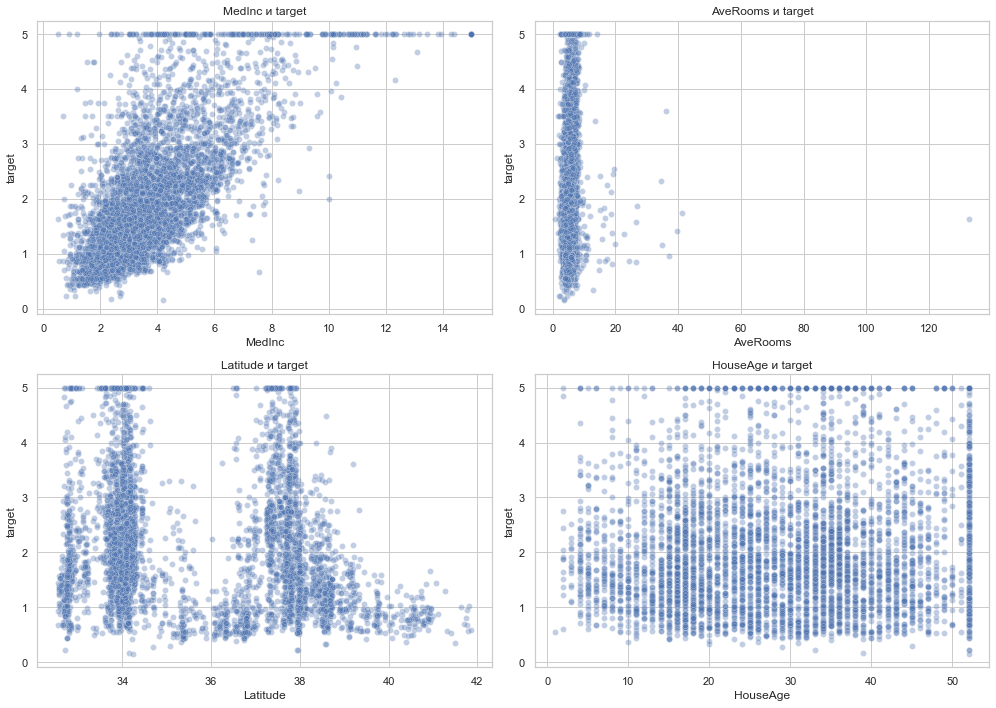

In [18]:
# ============================================================
# 13. Визуализация основных зависимостей
# ============================================================

top_features = target_correlations.head(4).index.tolist()

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.ravel()

sample_for_plot = df.sample(
    n=min(5000, len(df)),
    random_state=SEED
)

for ax, feature in zip(
    axes,
    top_features
):

    sns.scatterplot(
        data=sample_for_plot,
        x=feature,
        y='target',
        alpha=0.35,
        ax=ax
    )

    ax.set_title(
        f"{feature} и {'target'}"
    )

plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 14. Формирование X и y
# ============================================================

X = df.drop(
    columns=['target']
)

y = df['target']

print("\nРазмер матрицы признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)



Размер матрицы признаков X: (20640, 8)
Размер целевой переменной y: (20640,)


In [21]:
# ============================================================
# 15. Разделение данных
# ============================================================

# Сначала выделяем тестовую выборку
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

# Затем выделяем validation из train+validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=SEED
)

print("\nРазмеры выборок:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# Проверяем пересечение индексов
train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

print("\nПроверка пересечений:")
print(
    "Train и validation:",
    len(train_indices & val_indices)
)

print(
    "Train и test:",
    len(train_indices & test_indices)
)

print(
    "Validation и test:",
    len(val_indices & test_indices)
)




Размеры выборок:
Train: (13209, 8)
Validation: (3303, 8)
Test: (4128, 8)

Проверка пересечений:
Train и validation: 0
Train и test: 0
Validation и test: 0


In [22]:
# ============================================================
# 16. Обработка пропусков и стандартизация
# ============================================================

# Импутация и стандартизация обучаются только на train.
# Это предотвращает утечку информации из validation и test.

imputer = SimpleImputer(
    strategy="median"
)

scaler = StandardScaler()

# Обучение преобразований на train
X_train_imputed = imputer.fit_transform(
    X_train
)

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

# Применение преобразований к validation
X_val_imputed = imputer.transform(
    X_val
)

X_val_scaled = scaler.transform(
    X_val_imputed
)

# Применение преобразований к test
X_test_imputed = imputer.transform(
    X_test
)

X_test_scaled = scaler.transform(
    X_test_imputed
)

print(
    "\nРазмер стандартизированной train-выборки:",
    X_train_scaled.shape
)



Размер стандартизированной train-выборки: (13209, 8)


In [23]:
# ============================================================
# 17. Baseline: предсказание медианы
# ============================================================

baseline_model = DummyRegressor(
    strategy="median"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_results = {
    "model": "DummyRegressor median",
    "seed": SEED,
    "epochs_trained": np.nan,
    "best_val_loss": np.nan,
    "MAE": mean_absolute_error(
        y_test,
        baseline_predictions
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            baseline_predictions
        )
    ),
    "R2": r2_score(
        y_test,
        baseline_predictions
    )
}

print("\nBaseline: предсказание медианы")
display(
    pd.DataFrame(
        [baseline_results]
    )
)



Baseline: предсказание медианы


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
0,DummyRegressor median,42,NaN,NaN,0.874024,1.173666,-0.051192


In [24]:
# ============================================================
# 18. Baseline: линейная регрессия
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

linear_results = {
    "model": "LinearRegression",
    "seed": SEED,
    "epochs_trained": np.nan,
    "best_val_loss": np.nan,
    "MAE": mean_absolute_error(
        y_test,
        linear_predictions
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            linear_predictions
        )
    ),
    "R2": r2_score(
        y_test,
        linear_predictions
    )
}

print("\nBaseline: линейная регрессия")
display(
    pd.DataFrame(
        [linear_results]
    )
)



Baseline: линейная регрессия


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
0,LinearRegression,42,NaN,NaN,0.533474,0.744629,0.576871


In [34]:
# ============================================================
# 19. Функция создания нейронной сети
# ============================================================

def build_regression_model(
    
    input_dim,
    optimizer,
    seed=42
):
    """
    Создает многослойный перцептрон для регрессии.

    Архитектура:
    - входной слой;
    - Dense(64, ReLU);
    - Dense(32, ReLU);
    - Dense(1).

    Для регрессии у выходного слоя
    нет функции активации.
    """
    
    random.seed(seed)               # tf<2.9
    np.random.seed(seed)            # tf<2.9
    tf.random.set_seed(seed)        # tf<2.9 
    
    # Фиксируем seed перед созданием модели,
    # чтобы инициализация весов была воспроизводимой.
   # tf.keras.utils.set_random_seed(seed)               tf 2.9+

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            name="hidden_layer_1"
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu",
            name="hidden_layer_2"
        ),

        tf.keras.layers.Dense(
            1,
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model


In [35]:
# ============================================================
# 20. Функция оценки модели
# ============================================================

def evaluate_regression_model(
    model,
    X_data,
    y_data
):
    """
    Рассчитывает метрики регрессии.
    """

    predictions = model.predict(
        X_data,
        verbose=0
    ).ravel()

    metrics = {
        "MAE": mean_absolute_error(
            y_data,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_data,
                predictions
            )
        ),
        "R2": r2_score(
            y_data,
            predictions
        )
    }

    return metrics, predictions

In [36]:
# ============================================================
# 21. Функция обучения модели
# ============================================================

def train_model(
    optimizer,
    optimizer_name,
    seed=42,
    epochs=200,
    batch_size=32
):
    """
    Создает и обучает нейронную сеть.

    Валидационная выборка передается явно.
    EarlyStopping восстанавливает веса лучшей эпохи.
    """

    model = build_regression_model(
        input_dim=X_train_scaled.shape[1],
        optimizer=optimizer,
        seed=seed
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        mode="min"
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_val_scaled,
            y_val
        ),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[
            early_stopping
        ],
        verbose=0
    )

    test_metrics, test_predictions = (
        evaluate_regression_model(
            model,
            X_test_scaled,
            y_test
        )
    )

    result = {
        "model": optimizer_name,
        "seed": seed,
        "epochs_trained": len(
            history.history["loss"]
        ),
        "best_val_loss": min(
            history.history["val_loss"]
        ),
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "R2": test_metrics["R2"]
    }

    return (
        model,
        history,
        test_predictions,
        result
    )


In [41]:
# ============================================================
# 22. Функция создания оптимизатора
# ============================================================

def create_optimizer(optimizer_name):
    """
    Создает новый экземпляр оптимизатора.
    """

    if optimizer_name == "SGD":
        return tf.keras.optimizers.SGD(
            learning_rate=0.01
        )

    if optimizer_name == "SGD + momentum":
        return tf.keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9,
            nesterov=False
        )

    if optimizer_name == "SGD + Nesterov":
        return tf.keras.optimizers.SGD(
            learning_rate=0.001, 
            momentum=0.9,
            nesterov=True
        )

    if optimizer_name == "Adam":
        return tf.keras.optimizers.Adam(
            learning_rate=0.001
        )

    raise ValueError(
        f"Неизвестный оптимизатор: {optimizer_name}"
    )


In [42]:
# ============================================================
# 23. Обучение всех вариантов нейронной сети
# ============================================================

optimizer_names = [
    "SGD",
    "SGD + momentum",
    "SGD + Nesterov",
    "Adam"
]

trained_models = {}
histories = {}
predictions_by_name = {}
neural_network_results = []

for optimizer_name in optimizer_names:

    print(
        f"\nОбучение модели: {optimizer_name}"
    )

    optimizer = create_optimizer(
        optimizer_name
    )

    (
        model,
        history,
        test_predictions,
        result
    ) = train_model(
        optimizer=optimizer,
        optimizer_name=optimizer_name,
        seed=42,
        epochs=200,
        batch_size=32
    )

    trained_models[optimizer_name] = model
    histories[optimizer_name] = history
    predictions_by_name[optimizer_name] = (
        test_predictions
    )
    neural_network_results.append(result)

neural_network_results_df = pd.DataFrame(
    neural_network_results
)

print("\nРезультаты нейронных сетей:")
display(
    neural_network_results_df.sort_values(
        by="RMSE"
    )
)



Обучение модели: SGD

Обучение модели: SGD + momentum

Обучение модели: SGD + Nesterov

Обучение модели: Adam

Результаты нейронных сетей:


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
3,Adam,42,91,0.277333,0.351200,0.520485,0.793267
0,SGD,42,154,0.282000,0.356716,0.525646,0.789147
2,SGD + Nesterov,42,91,0.299544,0.368362,0.537993,0.779125
1,SGD + momentum,42,31,0.308140,0.373521,0.539720,0.777704


In [43]:
# ============================================================
# 24. Общее сравнение всех моделей
# ============================================================

all_results = pd.concat(
    [
        pd.DataFrame(
            [baseline_results]
        ),
        pd.DataFrame(
            [linear_results]
        ),
        neural_network_results_df
    ],
    ignore_index=True
)

print("\nОбщее сравнение моделей:")
display(
    all_results.sort_values(
        by="RMSE",
        ascending=True
    )
)


Общее сравнение моделей:


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
5,Adam,42,91.0,0.277333,0.351200,0.520485,0.793267
2,SGD,42,154.0,0.282000,0.356716,0.525646,0.789147
4,SGD + Nesterov,42,91.0,0.299544,0.368362,0.537993,0.779125
3,SGD + momentum,42,31.0,0.308140,0.373521,0.539720,0.777704
1,LinearRegression,42,NaN,NaN,0.533474,0.744629,0.576871
0,DummyRegressor median,42,NaN,NaN,0.874024,1.173666,-0.051192


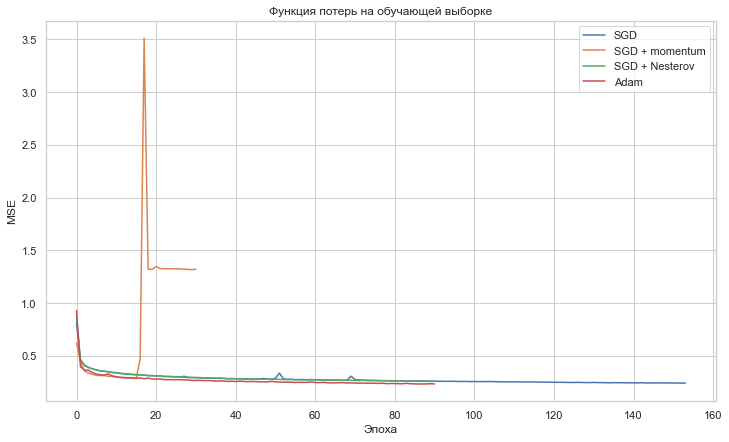

In [44]:
# ============================================================
# 25. Кривые обучения: train loss
# ============================================================

plt.figure(figsize=(12, 7))

for optimizer_name, history in histories.items():

    plt.plot(
        history.history["loss"],
        label=optimizer_name
    )

plt.title(
    "Функция потерь на обучающей выборке"
)

plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.legend()
plt.show()


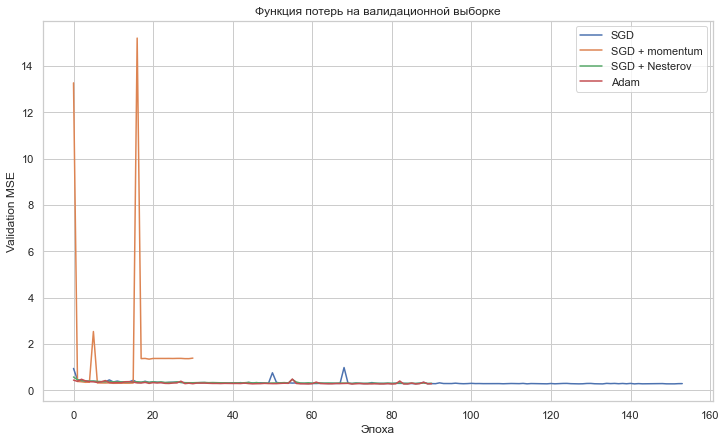

In [45]:
# ============================================================
# 26. Кривые обучения: validation loss
# ============================================================

plt.figure(figsize=(12, 7))

for optimizer_name, history in histories.items():

    plt.plot(
        history.history["val_loss"],
        label=optimizer_name
    )

plt.title(
    "Функция потерь на валидационной выборке"
)

plt.xlabel("Эпоха")
plt.ylabel("Validation MSE")
plt.legend()
plt.show()

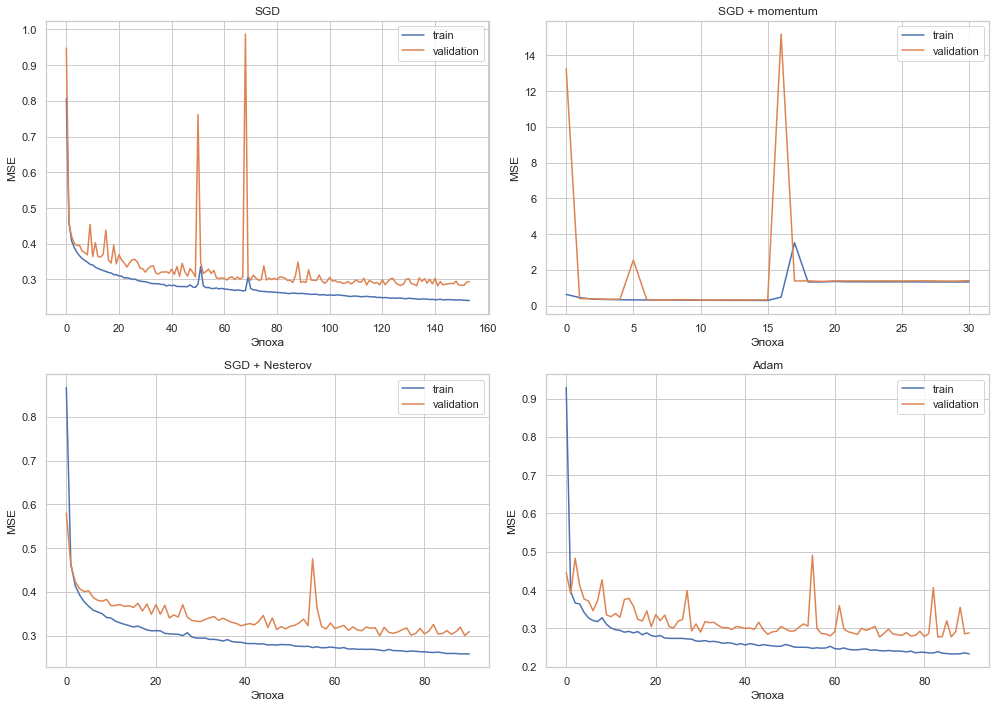

In [46]:
# ============================================================
# 27. Отдельные графики для всех моделей
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.ravel()

for ax, (
    optimizer_name,
    history
) in zip(
    axes,
    histories.items()
):

    ax.plot(
        history.history["loss"],
        label="train"
    )

    ax.plot(
        history.history["val_loss"],
        label="validation"
    )

    ax.set_title(
        optimizer_name
    )

    ax.set_xlabel("Эпоха")
    ax.set_ylabel("MSE")
    ax.legend()

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# 28. Выбор лучшей нейронной сети
# ============================================================

best_neural_network_name = (
    neural_network_results_df
    .loc[
        neural_network_results_df["RMSE"].idxmin(),
        "model"
    ]
)

best_model = trained_models[
    best_neural_network_name
]

best_predictions = predictions_by_name[
    best_neural_network_name
]

print(
    "\nЛучшая нейронная сеть:",
    best_neural_network_name
)


Лучшая нейронная сеть: Adam


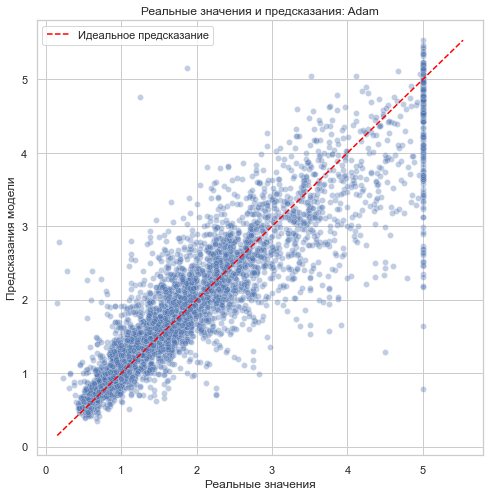

In [48]:
# ============================================================
# 29. Реальные значения против предсказаний
# ============================================================

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.35
)

minimum_value = min(
    y_test.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    color="red",
    linestyle="--",
    label="Идеальное предсказание"
)

plt.xlabel("Реальные значения")
plt.ylabel("Предсказания модели")

plt.title(
    "Реальные значения и предсказания: "
    + best_neural_network_name
)

plt.legend()
plt.show()


Первые строки таблицы ошибок:


,actual,prediction,residual,absolute_error
0,0.47700,0.508082,-0.031082,0.031082
1,0.45800,1.120716,-0.662716,0.662716
2,5.00001,4.658068,0.341942,0.341942
3,2.18600,2.287152,-0.101152,0.101152
4,2.78000,2.617575,0.162425,0.162425


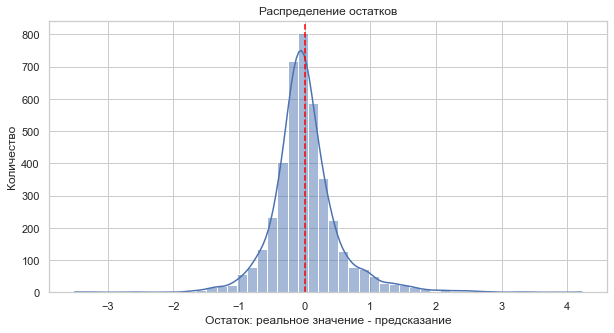

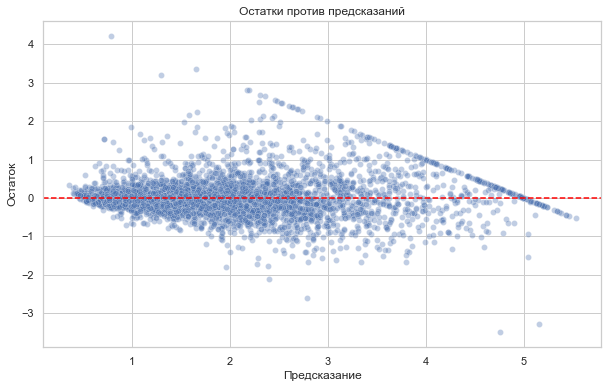

In [49]:
# ============================================================
# 30. Анализ остатков
# ============================================================

residuals = (
    y_test.to_numpy()
    - best_predictions
)

residuals_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "prediction": best_predictions,
    "residual": residuals,
    "absolute_error": np.abs(residuals)
})

print("\nПервые строки таблицы ошибок:")
display(
    residuals_df.head()
)

# Распределение остатков
plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Распределение остатков")
plt.xlabel(
    "Остаток: реальное значение - предсказание"
)
plt.ylabel("Количество")
plt.show()

# Остатки против предсказаний
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.35
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Предсказание")
plt.ylabel("Остаток")
plt.title("Остатки против предсказаний")
plt.show()

In [50]:
# ============================================================
# 31. Анализ ошибок по диапазонам целевой переменной
# ============================================================

error_analysis = residuals_df.copy()

error_analysis["target_group"] = pd.qcut(
    error_analysis["actual"],
    q=5,
    duplicates="drop"
)

grouped_errors = (
    error_analysis
    .groupby(
        "target_group",
        observed=False
    )
    .agg(
        count=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean")
    )
    .reset_index()
)

print(
    "\nОшибки по диапазонам целевой переменной:"
)

display(grouped_errors)


Ошибки по диапазонам целевой переменной:


,target_group,count,MAE,mean_residual
0,"(0.149, 1.069]",826,0.222507,-0.164048
1,"(1.069, 1.577]",827,0.270883,-0.145170
2,"(1.577, 2.071]",824,0.285052,-0.094572
3,"(2.071, 2.874]",825,0.363060,0.016089
4,"(2.874, 5.0]",826,0.614452,0.425845


In [51]:
# ============================================================
# 32. Объекты с наибольшими ошибками
# ============================================================

largest_errors = (
    error_analysis
    .sort_values(
        by="absolute_error",
        ascending=False
    )
    .head(20)
)

print(
    "\nОбъекты с наибольшими ошибками:"
)

display(largest_errors)


# Добавляем исходные признаки объектов
largest_error_indices = X_test.loc[
    largest_errors.index
].copy()

largest_error_indices["actual"] = (
    largest_errors["actual"]
)

largest_error_indices["prediction"] = (
    largest_errors["prediction"]
)

largest_error_indices["absolute_error"] = (
    largest_errors["absolute_error"]
)

print(
    "\nПризнаки объектов с наибольшими ошибками:"
)

display(largest_error_indices)


Объекты с наибольшими ошибками:


,actual,prediction,residual,absolute_error,target_group
1649,5.00001,0.780137,4.219873,4.219873,"(2.874, 5.0]"
285,1.25000,4.753176,-3.503176,3.503176,"(1.069, 1.577]"
1865,5.00001,1.645833,3.354177,3.354177,"(2.874, 5.0]"
2558,1.87500,5.154538,-3.279538,3.279538,"(1.577, 2.071]"
3710,4.50000,1.292933,3.207067,3.207067,"(2.874, 5.0]"
872,5.00001,2.176510,2.823500,2.823500,"(2.874, 5.0]"
3054,5.00001,2.189236,2.810774,2.810774,"(2.874, 5.0]"
3693,5.00001,2.306772,2.693238,2.693238,"(2.874, 5.0]"
1140,5.00001,2.350943,2.649067,2.649067,"(2.874, 5.0]"
2927,0.17500,2.782449,-2.607449,2.607449,"(0.149, 1.069]"


KeyError: "Passing list-likes to .loc or [] with any missing labels is no longer supported. The following labels were missing: Int64Index([1649, 1865, 2558,  872, 3054,\n            ...\n            3607,  429, 3761, 2785, 1253],\n           dtype='int64', length=16). See https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#deprecate-loc-reindex-listlike"

In [52]:
# ============================================================
# 33. Повторение эксперимента на нескольких seed
# ============================================================

seed_results = []

for current_seed in SEEDS_FOR_EXPERIMENT:

    print(
        f"Обучение Adam для seed={current_seed}"
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    (
        _,
        _,
        _,
        result
    ) = train_model(
        optimizer=optimizer,
        optimizer_name="Adam",
        seed=current_seed,
        epochs=200,
        batch_size=32
    )

    seed_results.append(result)

seed_results_df = pd.DataFrame(
    seed_results
)

print(
    "\nРезультаты Adam на разных seed:"
)

display(seed_results_df)


# Средние значения и разброс
stability_summary = (
    seed_results_df
    .agg({
        "MAE": [
            "mean",
            "std",
            "min",
            "max"
        ],
        "RMSE": [
            "mean",
            "std",
            "min",
            "max"
        ],
        "R2": [
            "mean",
            "std",
            "min",
            "max"
        ],
        "epochs_trained": [
            "mean",
            "std"
        ]
    })
)

print(
    "\nСредние значения и разброс:"
)

display(stability_summary)


Обучение Adam для seed=1
Обучение Adam для seed=2
Обучение Adam для seed=3
Обучение Adam для seed=4
Обучение Adam для seed=5

Результаты Adam на разных seed:


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
0,Adam,1,93,0.276233,0.358203,0.525856,0.788979
1,Adam,2,88,0.282177,0.367636,0.527863,0.787364
2,Adam,3,124,0.265875,0.342686,0.514827,0.797737
3,Adam,4,84,0.274469,0.351228,0.519476,0.794068
4,Adam,5,78,0.279286,0.354421,0.523468,0.790891



Средние значения и разброс:


,MAE,RMSE,R2,epochs_trained
max,0.367636,0.527863,0.797737,NaN
mean,0.354835,0.522298,0.791808,93.400000
min,0.342686,0.514827,0.787364,NaN
std,0.009165,0.005215,0.004149,17.966636


In [53]:
# ============================================================
# 34. Сравнение оптимизаторов на нескольких seed
# ============================================================

repeated_results = []

for optimizer_name in optimizer_names:

    for current_seed in SEEDS_FOR_EXPERIMENT:

        print(
            f"Модель: {optimizer_name}; "
            f"seed: {current_seed}"
        )

        optimizer = create_optimizer(
            optimizer_name
        )

        (
            _,
            _,
            _,
            result
        ) = train_model(
            optimizer=optimizer,
            optimizer_name=optimizer_name,
            seed=current_seed,
            epochs=200,
            batch_size=32
        )

        repeated_results.append(result)

repeated_results_df = pd.DataFrame(
    repeated_results
)

print(
    "\nРезультаты всех оптимизаторов "
    "на нескольких seed:"
)

display(repeated_results_df)


# Сводная таблица
optimizer_summary = (
    repeated_results_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
        epochs_mean=("epochs_trained", "mean")
    )
    .sort_values(
        by="RMSE_mean"
    )
)

print(
    "\nСводная таблица по оптимизаторам:"
)

display(optimizer_summary)


Модель: SGD; seed: 1
Модель: SGD; seed: 2
Модель: SGD; seed: 3
Модель: SGD; seed: 4
Модель: SGD; seed: 5
Модель: SGD + momentum; seed: 1
Модель: SGD + momentum; seed: 2
Модель: SGD + momentum; seed: 3
Модель: SGD + momentum; seed: 4
Модель: SGD + momentum; seed: 5
Модель: SGD + Nesterov; seed: 1
Модель: SGD + Nesterov; seed: 2
Модель: SGD + Nesterov; seed: 3
Модель: SGD + Nesterov; seed: 4
Модель: SGD + Nesterov; seed: 5
Модель: Adam; seed: 1
Модель: Adam; seed: 2
Модель: Adam; seed: 3
Модель: Adam; seed: 4
Модель: Adam; seed: 5

Результаты всех оптимизаторов на нескольких seed:


,model,seed,epochs_trained,best_val_loss,MAE,RMSE,R2
0,SGD,1,200,0.276890,0.356088,0.533552,0.782756
1,SGD,2,57,0.301682,0.372120,0.539979,0.777492
2,SGD,3,183,0.271552,0.346636,0.518421,0.794903
3,SGD,4,178,0.273002,0.347573,0.518369,0.794945
4,SGD,5,21,10.576571,0.542078,0.788869,0.525100
5,SGD + momentum,1,21,171.106216,1.059843,9.982707,-75.048354
6,SGD + momentum,2,23,0.357991,0.402153,0.587366,0.736724
7,SGD + momentum,3,22,0.375021,0.427382,0.594112,0.730642
8,SGD + momentum,4,23,0.349630,0.406536,0.581500,0.741957
9,SGD + momentum,5,42,0.295403,0.369986,0.545215,0.773155



Сводная таблица по оптимизаторам:


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,epochs_mean
model,,,,,,,
SGD + Nesterov,0.351719,0.003307,0.521286,0.003258,0.792624,0.002599,176.2
Adam,0.354835,0.009165,0.522298,0.005215,0.791808,0.004149,93.4
SGD,0.392899,0.084018,0.579838,0.117234,0.735039,0.117608,127.8
SGD + momentum,0.533180,0.295130,2.458180,4.206381,-14.413175,33.896100,26.2


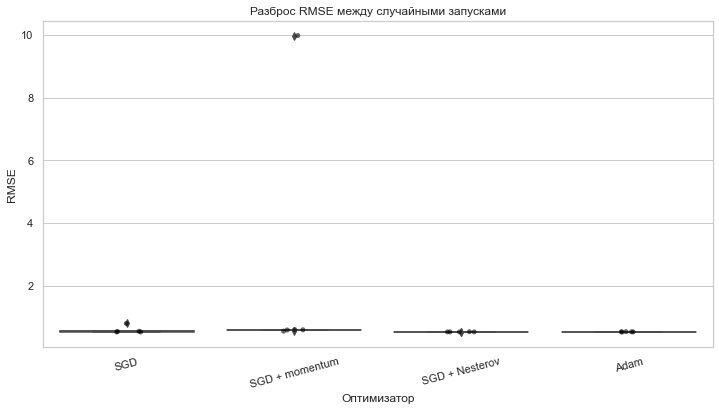

In [54]:
# ============================================================
# 35. Визуализация разброса между запусками
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=repeated_results_df,
    x="model",
    y="RMSE"
)

sns.stripplot(
    data=repeated_results_df,
    x="model",
    y="RMSE",
    color="black",
    alpha=0.6
)

plt.title(
    "Разброс RMSE между случайными запусками"
)

plt.xlabel("Оптимизатор")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

Доля обучающей выборки: 0.2
Доля обучающей выборки: 0.4
Доля обучающей выборки: 0.6
Доля обучающей выборки: 0.8
Доля обучающей выборки: 1.0

Результаты эксперимента с размером обучающей выборки:


,train_fraction,train_size,MAE,RMSE,R2
0,0.2,2641,0.457561,0.642380,0.685097
1,0.4,5283,0.372108,0.548964,0.770025
2,0.6,7925,0.367416,0.536265,0.780541
3,0.8,10567,0.357743,0.523819,0.790610
4,1.0,13209,0.351200,0.520485,0.793267


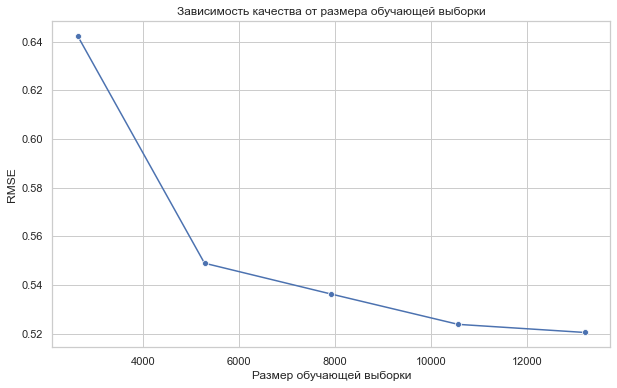

In [55]:
# ============================================================
# 36. Эксперимент с размером обучающей выборки
# ============================================================

train_fractions = [
    0.2,
    0.4,
    0.6,
    0.8,
    1.0
]

learning_curve_results = []

for fraction in train_fractions:

    print(
        f"Доля обучающей выборки: {fraction}"
    )

    if fraction < 1.0:

        X_partial, _, y_partial, _ = (
            train_test_split(
                X_train_scaled,
                y_train,
                train_size=fraction,
                random_state=SEED
            )
        )

    else:

        X_partial = X_train_scaled
        y_partial = y_train

    model = build_regression_model(
        input_dim=X_train_scaled.shape[1],
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        seed=SEED
    )

    early_stopping = (
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    )

    model.fit(
        X_partial,
        y_partial,
        validation_data=(
            X_val_scaled,
            y_val
        ),
        epochs=200,
        batch_size=32,
        callbacks=[
            early_stopping
        ],
        verbose=0
    )

    metrics, _ = evaluate_regression_model(
        model,
        X_test_scaled,
        y_test
    )

    learning_curve_results.append({
        "train_fraction": fraction,
        "train_size": len(X_partial),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

learning_curve_df = pd.DataFrame(
    learning_curve_results
)

print(
    "\nРезультаты эксперимента "
    "с размером обучающей выборки:"
)

display(learning_curve_df)


# График зависимости качества от размера train
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=learning_curve_df,
    x="train_size",
    y="RMSE",
    marker="o"
)

plt.title(
    "Зависимость качества от размера "
    "обучающей выборки"
)

plt.xlabel(
    "Размер обучающей выборки"
)

plt.ylabel("RMSE")
plt.show()


Learning rate: 0.0001
Learning rate: 0.0005
Learning rate: 0.001
Learning rate: 0.005
Learning rate: 0.01

Результаты эксперимента с learning rate:


,learning_rate,epochs_trained,best_val_loss,MAE,RMSE,R2
0,0.0001,187,0.304357,0.374803,0.544839,0.773468
1,0.0005,105,0.286801,0.359901,0.532001,0.784018
2,0.0010,91,0.277333,0.351200,0.520485,0.793267
3,0.0050,86,0.280869,0.349526,0.519731,0.793866
4,0.0100,67,0.281713,0.369815,0.541977,0.775841


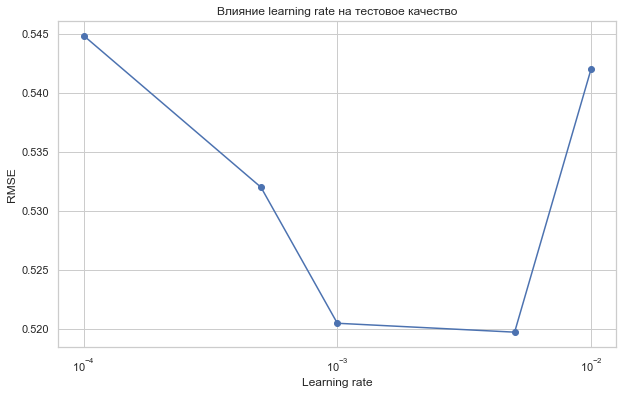

In [56]:
# ============================================================
# 37. Эксперимент с learning rate
# ============================================================

learning_rates = [
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01
]

learning_rate_results = []

for learning_rate in learning_rates:

    print(
        f"Learning rate: {learning_rate}"
    )

    model = build_regression_model(
        input_dim=X_train_scaled.shape[1],
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        seed=SEED
    )

    early_stopping = (
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_val_scaled,
            y_val
        ),
        epochs=200,
        batch_size=32,
        callbacks=[
            early_stopping
        ],
        verbose=0
    )

    metrics, _ = evaluate_regression_model(
        model,
        X_test_scaled,
        y_test
    )

    learning_rate_results.append({
        "learning_rate": learning_rate,
        "epochs_trained": len(
            history.history["loss"]
        ),
        "best_val_loss": min(
            history.history["val_loss"]
        ),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

learning_rate_df = pd.DataFrame(
    learning_rate_results
)

print(
    "\nРезультаты эксперимента "
    "с learning rate:"
)

display(learning_rate_df)


# Визуализация влияния learning rate
plt.figure(figsize=(10, 6))

plt.semilogx(
    learning_rate_df["learning_rate"],
    learning_rate_df["RMSE"],
    marker="o"
)

plt.xlabel("Learning rate")
plt.ylabel("RMSE")

plt.title(
    "Влияние learning rate "
    "на тестовое качество"
)

plt.show()

In [58]:
# ============================================================
# 38. Сохранение результатов
# ============================================================

os.makedirs(
    "results",
    exist_ok=True
)

# Сохраняем основные таблицы
all_results.to_csv(
    "results/main_results.csv",
    index=False
)

neural_network_results_df.to_csv(
    "results/neural_network_results.csv",
    index=False
)

repeated_results_df.to_csv(
    "results/repeated_results.csv",
    index=False
)

optimizer_summary.to_csv(
    "results/optimizer_summary.csv"
)

learning_curve_df.to_csv(
    "results/learning_curve_results.csv",
    index=False
)

learning_rate_df.to_csv(
    "results/learning_rate_results.csv",
    index=False
)

error_analysis.to_csv(
    "results/error_analysis.csv",
    index=False
)

outlier_table.to_csv(
    "results/outlier_table.csv",
    index=False
)

print(
    "\nТаблицы сохранены в директорию results/"
)



Таблицы сохранены в директорию results/


In [59]:
# ============================================================
# 39. Сохранение модели и preprocessing
# ============================================================

# Сохраняем лучшую нейронную сеть
best_model.save(
    "results/best_regression_model.keras"
)

# Сохраняем объекты обработки данных
import joblib

joblib.dump(
    imputer,
    "results/imputer.joblib"
)

joblib.dump(
    scaler,
    "results/scaler.joblib"
)

print(
    "Модель и preprocessing сохранены."
)


Модель и preprocessing сохранены.


In [61]:
# ============================================================
# 40. Формирование итогового текстового отчета
# ============================================================

best_row = (
    all_results
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .iloc[0]
)

report_text = f"""
ОТЧЕТ ПО ЭКСПЕРИМЕНТУ

Исследовательский вопрос:
{research_question}

Гипотеза:
{hypothesis}

Размер исходного набора данных:
{df.shape}

Количество признаков:
{X.shape[1]}

Размер train:
{X_train.shape}

Размер validation:
{X_val.shape}

Размер test:
{X_test.shape}

Лучшая модель по RMSE:
{best_row["model"]}

MAE:
{best_row["MAE"]:.5f}

RMSE:
{best_row["RMSE"]:.5f}

R2:
{best_row["R2"]:.5f}

результат необходимо интерпретировать с учетом baseline,
разброса между случайными запусками, выбранного набора данных,
архитектуры и гиперпараметров.

Нельзя автоматически утверждать, что выбранный метод
будет лучшим на других наборах данных.
"""

with open(
    "results/experiment_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report_text)

print("\nИтоговый отчет:")
print(report_text)





Итоговый отчет:

ОТЧЕТ ПО ЭКСПЕРИМЕНТУ

Исследовательский вопрос:
Как выбор оптимизатора влияет на качество и скорость обучения нейронной сети при прогнозировании стоимости жилья?

Гипотеза:
SGD с momentum и Adam будут сходиться быстрее обычного SGD и дадут меньшую ошибку на тестовой выборке.

Размер исходного набора данных:
(20640, 9)

Количество признаков:
8

Размер train:
(13209, 8)

Размер validation:
(3303, 8)

Размер test:
(4128, 8)

Лучшая модель по RMSE:
Adam

MAE:
0.35120

RMSE:
0.52048

R2:
0.79327

результат необходимо интерпретировать с учетом baseline,
разброса между случайными запусками, выбранного набора данных,
архитектуры и гиперпараметров.

Нельзя автоматически утверждать, что выбранный метод
будет лучшим на других наборах данных.



In [62]:
# ============================================================
# 41. Контрольный список курсовой работы
# ============================================================

checklist = {
    "Выбран набор данных": False,
    "Указан источник данных": False,
    "Сформулирован исследовательский вопрос": False,
    "Сформулирована гипотеза": False,
    "Определена целевая переменная": False,
    "Выбран тип задачи": False,
    "Проведен EDA": False,
    "Проверены пропуски": False,
    "Проверены дубликаты": False,
    "Проверены выбросы": False,
    "Построен baseline": False,
    "Выбраны метрики": False,
    "Определен основной фактор эксперимента": False,
    "Спланировано сравнение": False,
    "Проведен анализ ошибок": False,
    "Проверено несколько random seed": False,
    "Сохранены результаты экспериментов": False,
    "Описаны ограничения исследования": False
}

checklist_df = pd.DataFrame({
    "Элемент": list(checklist.keys()),
    "Готово": list(checklist.values())
})

print(
    "\nКонтрольный список курсовой работы:"
)

display(checklist_df)





Контрольный список курсовой работы:


,Элемент,Готово
0,Выбран набор данных,False
1,Указан источник данных,False
2,Сформулирован исследовательский вопрос,False
3,Сформулирована гипотеза,False
4,Определена целевая переменная,False
5,Выбран тип задачи,False
6,Проведен EDA,False
7,Проверены пропуски,False
8,Проверены дубликаты,False
9,Проверены выбросы,False


In [63]:
# ============================================================
# 42. Шаблон итогового вывода
# ============================================================

conclusion_template = f"""
ИТОГОВЫЙ ШАБЛОН ВЫВОДА

В работе исследовалось влияние выбора оптимизатора
на качество и скорость обучения нейронной сети
для задачи прогнозирования стоимости жилья.

В качестве данных использовался набор California Housing.

В качестве baseline применялись:
1. предсказание медианного значения;
2. линейная регрессия.

Основной моделью являлся многослойный перцептрон
с двумя скрытыми слоями.

Сравнивались следующие оптимизаторы:
SGD, SGD с momentum, SGD с Nesterov momentum и Adam.

Качество оценивалось по метрикам MAE, RMSE и R2.

Лучшая модель:
{best_row["model"]}

Ее значение RMSE:
{best_row["RMSE"]:.5f}

Гипотеза должна быть оценена путем сравнения:
1. качества моделей;
2. скорости обучения;
3. результатов на нескольких random seed;
4. устойчивости к изменению learning rate;
5. результатов на разных размерах обучающей выборки.

Полученный вывод ограничен выбранным набором данных,
архитектурой модели, значениями гиперпараметров
и используемым экспериментальным протоколом.
"""

print(conclusion_template)


ИТОГОВЫЙ ШАБЛОН ВЫВОДА

В работе исследовалось влияние выбора оптимизатора
на качество и скорость обучения нейронной сети
для задачи прогнозирования стоимости жилья.

В качестве данных использовался набор California Housing.

В качестве baseline применялись:
1. предсказание медианного значения;
2. линейная регрессия.

Основной моделью являлся многослойный перцептрон
с двумя скрытыми слоями.

Сравнивались следующие оптимизаторы:
SGD, SGD с momentum, SGD с Nesterov momentum и Adam.

Качество оценивалось по метрикам MAE, RMSE и R2.

Лучшая модель:
Adam

Ее значение RMSE:
0.52048

Гипотеза должна быть оценена путем сравнения:
1. качества моделей;
2. скорости обучения;
3. результатов на нескольких random seed;
4. устойчивости к изменению learning rate;
5. результатов на разных размерах обучающей выборки.

Полученный вывод ограничен выбранным набором данных,
архитектурой модели, значениями гиперпараметров
и используемым экспериментальным протоколом.

